## Notebook 2: Dataset Integration and Comparative Analysis of Workforce, Migration and Employment Trends

## Introduction
This notebook integrates the Skills for Care, Home Office, and Office for National Statistics (ONS) datasets to examine the relationships between workforce indicators, international recruitment, and migrant employment trends in the UK adult social care sector. Comparative visualisations and cross-correlation analysis are used to investigate how these variables interact over time and to address the study's research objectives.

# Part I: Dataset Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler

In [2]:
# Load Skills for Care dataset
sfc = pd.read_excel("../02_Clean_Data/Skills_for_Care/Skills_for_Care_Cleaned_Dataset.xlsx")

# Load Home Office dataset
ho = pd.read_excel("../02_Clean_Data/Home_Office/Home_Office_Cleaned_Dataset.xlsx")

# Load ONS dataset
ons = pd.read_excel("../02_Clean_Data/ONS/Cleaned_ONS_Country_Of_Birth_Datatset.xlsx")

**Interpretation**:
The three cleaned datasets were successfully imported and are ready for preparation and integration.

## 2. Prepare the Home Office Dataset

The Home Office dataset is aggregated to annual totals to align its temporal resolution with the annual Skills for Care dataset. This enables meaningful comparison across the three datasets without introducing artificial observations.

In [3]:
# Aggregate quarterly visa grants to annual totals
ho_annual = (
    ho.groupby('Year', as_index=False)['Visa_Grants']
      .sum()
)

ho_annual.head()

,Year,Visa_Grants
0,2021,3413
1,2022,37031
2,2023,107772
3,2024,9539
4,2025,3172


In [4]:
ho_annual.to_excel(
    "../04_Output/Tables/HomeOffice_Annual_Dataset.xlsx",
    index=False
)

print("Home Office annual dataset exported successfully.")

Home Office annual dataset exported successfully.


**Interpretation**:
Quarterly Health and Care Worker visa grants were aggregated into annual totals to facilitate comparison with the annual workforce indicators from the Skills for Care dataset.

## 3. Prepare the ONS Dataset

The ONS dataset contains quarterly employment observations. To align with the annual Skills for Care dataset, quarterly employment levels and employment rates are averaged for each year. Annual averages provide a representative measure of employment while avoiding the overestimation that would result from summing quarterly observations.

In [5]:
# Aggregate ONS data to annual averages
ons_annual = (
    ons.groupby('Year', as_index=False)
       .agg({
           'Tot_Emp':'mean',
           'UK_Born_Emp':'mean',
           'NonUK_Born_Emp':'mean',
           'EU27_Emp':'mean',
           'NonEU_Emp':'mean',
           'Tot_Emp_Rt':'mean',
           'UK_Emp_Rt':'mean',
           'NonUK_Emp_Rt':'mean',
           'EU27_Emp_Rt':'mean',
           'NonEU_Emp_Rt':'mean'
       })
       .round(2)
)

ons_annual.head()

,Year,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt
0,1997,26522.75,24546.75,1975.00,651.50,1323.50,71.01,71.86,61.89,66.55,59.86
1,1998,26793.50,24712.75,2079.75,700.00,1379.75,71.47,72.37,62.31,67.02,60.19
2,1999,27167.00,25049.50,2115.50,697.25,1418.25,72.03,72.96,62.61,68.23,60.20
3,2000,27483.50,25272.00,2209.50,710.50,1499.25,72.47,73.47,62.69,68.51,60.34
4,2001,27711.50,25396.75,2310.75,724.75,1586.25,72.61,73.61,63.14,69.61,60.61


In [6]:
ons_annual.to_excel(
    "../04_Output/Tables/ONS_Annual_Dataset.xlsx",
    index=False
)

print("ONS annual dataset exported successfully.")

ONS annual dataset exported successfully.


**Interpretation**:
Quarterly employment levels and employment rates were averaged to produce one representative observation per year. This preserves the annual employment pattern while ensuring consistency with the annual Skills for Care dataset.

## 4. Merge the Datasets

The annual Skills for Care, Home Office, and ONS datasets are merged using **Year** as the common identifier. This creates a unified analytical dataset for comparative analysis and cross-correlation.

In [7]:
# Merge Skills for Care and Home Office
merged = pd.merge(
    sfc,
    ho_annual,
    on='Year',
    how='inner'
)

# Merge with ONS
merged = pd.merge(
    merged,
    ons_annual,
    on='Year',
    how='inner'
)

merged.head()

,Period,Year,Tot_Posts,Filled_Posts,FTE_Filled_Posts,FTE_Ratio,Employees,Turnover_Rt,Leavers,Vacancy_Rt,...,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt
0,2020/21,2021,1005000,940000,715000,0.761,845000,0.318,270000,0.074,...,32551.50,27081.50,5465.00,2046.25,3418.75,74.81,74.89,74.69,81.38,71.17
1,2021/22,2022,1030000,925000,700000,0.759,830000,0.330,275000,0.113,...,32955.50,26767.25,6180.25,2227.50,3953.25,75.06,75.08,75.16,82.07,71.73
2,2022/23,2023,1065000,960000,740000,0.768,855000,0.323,275000,0.109,...,33348.75,26637.75,6702.50,2282.75,4419.75,75.05,74.96,75.56,81.75,72.68
3,2023/24,2024,1105000,1015000,795000,0.783,905000,0.276,249000,0.090,...,33612.75,26629.00,6981.25,2239.50,4742.25,74.73,74.55,75.59,80.60,73.43
4,2024/25,2025,1135000,1055000,835000,0.792,945000,0.262,248000,0.076,...,34160.00,26875.25,7277.75,2266.75,5011.50,75.07,74.66,76.79,81.33,74.89


**Interpretation**:
The three annual datasets were successfully integrated using the Year variable, producing a single analytical dataset containing workforce indicators, visa grants, and employment measures.

## 5. Inspect the Merged Dataset

The merged dataset is inspected to verify that all variables have been integrated correctly before comparative analysis begins.

In [8]:
merged.head()

,Period,Year,Tot_Posts,Filled_Posts,FTE_Filled_Posts,FTE_Ratio,Employees,Turnover_Rt,Leavers,Vacancy_Rt,...,Tot_Emp,UK_Born_Emp,NonUK_Born_Emp,EU27_Emp,NonEU_Emp,Tot_Emp_Rt,UK_Emp_Rt,NonUK_Emp_Rt,EU27_Emp_Rt,NonEU_Emp_Rt
0,2020/21,2021,1005000,940000,715000,0.761,845000,0.318,270000,0.074,...,32551.50,27081.50,5465.00,2046.25,3418.75,74.81,74.89,74.69,81.38,71.17
1,2021/22,2022,1030000,925000,700000,0.759,830000,0.330,275000,0.113,...,32955.50,26767.25,6180.25,2227.50,3953.25,75.06,75.08,75.16,82.07,71.73
2,2022/23,2023,1065000,960000,740000,0.768,855000,0.323,275000,0.109,...,33348.75,26637.75,6702.50,2282.75,4419.75,75.05,74.96,75.56,81.75,72.68
3,2023/24,2024,1105000,1015000,795000,0.783,905000,0.276,249000,0.090,...,33612.75,26629.00,6981.25,2239.50,4742.25,74.73,74.55,75.59,80.60,73.43
4,2024/25,2025,1135000,1055000,835000,0.792,945000,0.262,248000,0.076,...,34160.00,26875.25,7277.75,2266.75,5011.50,75.07,74.66,76.79,81.33,74.89


In [9]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Period            6 non-null      object 
 1   Year              6 non-null      int64  
 2   Tot_Posts         6 non-null      int64  
 3   Filled_Posts      6 non-null      int64  
 4   FTE_Filled_Posts  6 non-null      int64  
 5   FTE_Ratio         6 non-null      float64
 6   Employees         6 non-null      int64  
 7   Turnover_Rt       6 non-null      float64
 8   Leavers           6 non-null      int64  
 9   Vacancy_Rt        6 non-null      float64
 10  Vacant_Posts      6 non-null      int64  
 11  Starters_Rt       6 non-null      float64
 12  Starters          6 non-null      int64  
 13  Visa_Grants       6 non-null      int64  
 14  Tot_Emp           6 non-null      float64
 15  UK_Born_Emp       6 non-null      float64
 16  NonUK_Born_Emp    6 non-null      float64
 17  E

In [10]:
merged.isnull().sum()

Period              0
Year                0
Tot_Posts           0
Filled_Posts        0
FTE_Filled_Posts    0
FTE_Ratio           0
Employees           0
Turnover_Rt         0
Leavers             0
Vacancy_Rt          0
Vacant_Posts        0
Starters_Rt         0
Starters            0
Visa_Grants         0
Tot_Emp             0
UK_Born_Emp         0
NonUK_Born_Emp      0
EU27_Emp            0
NonEU_Emp           0
Tot_Emp_Rt          0
UK_Emp_Rt           0
NonUK_Emp_Rt        0
EU27_Emp_Rt         0
NonEU_Emp_Rt        0
dtype: int64

**Interpretation**:
The merged dataset contains the variables required for comparative analysis and no missing values were identified following integration.

# Part II: Comparative Analysis

## 1. Visa Grants and Workforce Vacancy Trends

Health and Care Worker visa grants and workforce vacancy rates are compared to examine whether changes in international recruitment correspond with changes in workforce shortages. Since the two variables are measured on different scales, they are standardised using z-scores to enable direct comparison of their temporal trends.

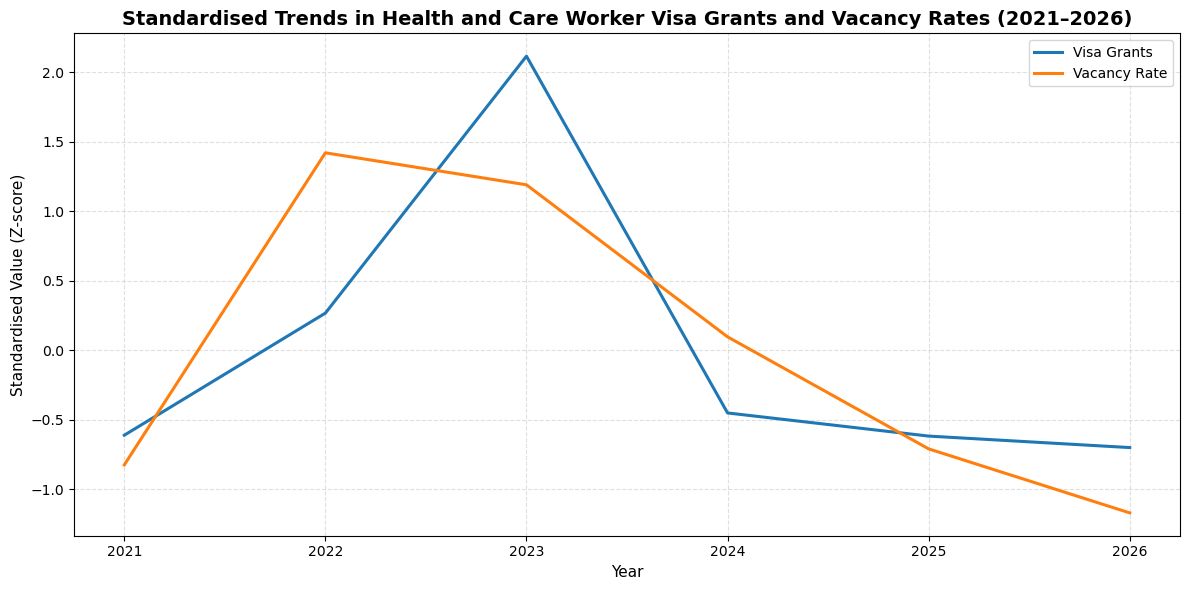

In [11]:
# Select variables
visa_vacancy = merged[['Year',
                       'Visa_Grants',
                       'Vacancy_Rt']].copy()

# Standardise variables
scaler = StandardScaler()

visa_vacancy[['Visa_Grants',
              'Vacancy_Rt']] = scaler.fit_transform(
    visa_vacancy[['Visa_Grants',
                  'Vacancy_Rt']]
)

# Create figure
plt.figure(figsize=(12,6))

# Plot variables
plt.plot(
    visa_vacancy['Year'],
    visa_vacancy['Visa_Grants'],
    linewidth=2.2,
    label='Visa Grants'
)

plt.plot(
    visa_vacancy['Year'],
    visa_vacancy['Vacancy_Rt'],
    linewidth=2.2,
    label='Vacancy Rate'
)

# Titles and labels
plt.title(
    'Standardised Trends in Health and Care Worker Visa Grants and Vacancy Rates (2021–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Standardised Value (Z-score)', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)
plt.tight_layout()

plt.savefig(
    "../04_Output/Figures/Visa_Grants_vs_Vacancy_Rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation**
The figure compares the standardised annual trends in Health and Care Worker visa grants and workforce vacancy rates between 2021 and 2026. Both variables increased until 2023 before declining thereafter, although vacancy rates peaked earlier than visa grants. This suggests that changes in workforce shortages and international recruitment followed similar but not identical patterns. The potential lagged relationship is explored further using cross-correlation analysis.

## 2. Visa Grants and Non-UK Employment Trends

Health and Care Worker visa grants are compared with non-UK-born employment to examine whether increases in international recruitment were associated with changes in migrant employment. The variables are standardised to enable comparison despite differences in their original scales.

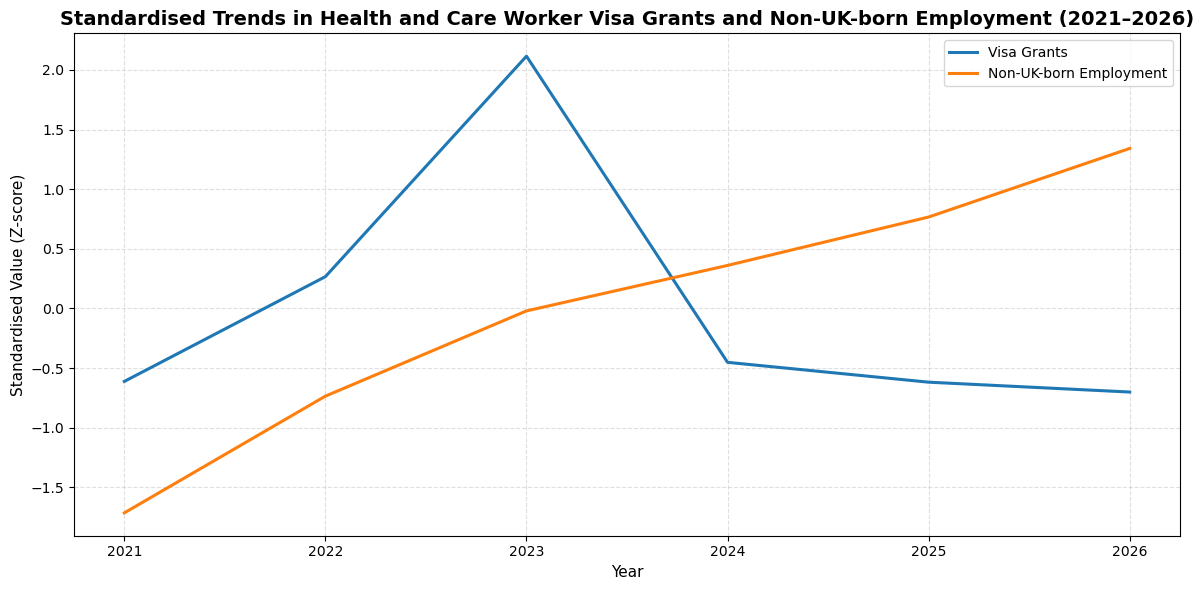

In [12]:
# Select variables
visa_employment = merged[['Year',
                          'Visa_Grants',
                          'NonUK_Born_Emp']].copy()

# Standardise variables
scaler = StandardScaler()

visa_employment[['Visa_Grants',
                 'NonUK_Born_Emp']] = scaler.fit_transform(
    visa_employment[['Visa_Grants',
                     'NonUK_Born_Emp']]
)

# Create figure
plt.figure(figsize=(12,6))

# Plot variables
plt.plot(
    visa_employment['Year'],
    visa_employment['Visa_Grants'],
    linewidth=2.2,
    label='Visa Grants'
)

plt.plot(
    visa_employment['Year'],
    visa_employment['NonUK_Born_Emp'],
    linewidth=2.2,
    label='Non-UK-born Employment'
)

# Titles and labels
plt.title(
    'Standardised Trends in Health and Care Worker Visa Grants and Non-UK-born Employment (2021–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Standardised Value (Z-score)', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)
plt.tight_layout()

plt.savefig(
    "../04_Output/Figures/Visa_Grants_vs_NonUK_Employment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation**:
The figure compares the standardised annual trends in Health and Care Worker visa grants and non-UK-born employment between 2021 and 2026. Visa grants increased rapidly between 2021 and 2023 before declining sharply over the remaining years. In contrast, non-UK-born employment increased steadily throughout the study period, continuing to rise even after visa grants began to fall. The differing trajectories suggest that changes in migrant employment did not occur simultaneously with changes in visa grants and may reflect delayed or more complex relationships between international recruitment and employment outcomes. These relationships are explored further using cross-correlation analysis.

## 3. Comparative Trends in International Recruitment, Workforce Vacancies and Migrant Employment

Health and Care Worker visa grants, workforce vacancy rates, and non-UK-born employment are compared on a single standardised graph. Visualising these variables together provides an overview of how international recruitment, migrant employment, and workforce shortages evolved over the study period.

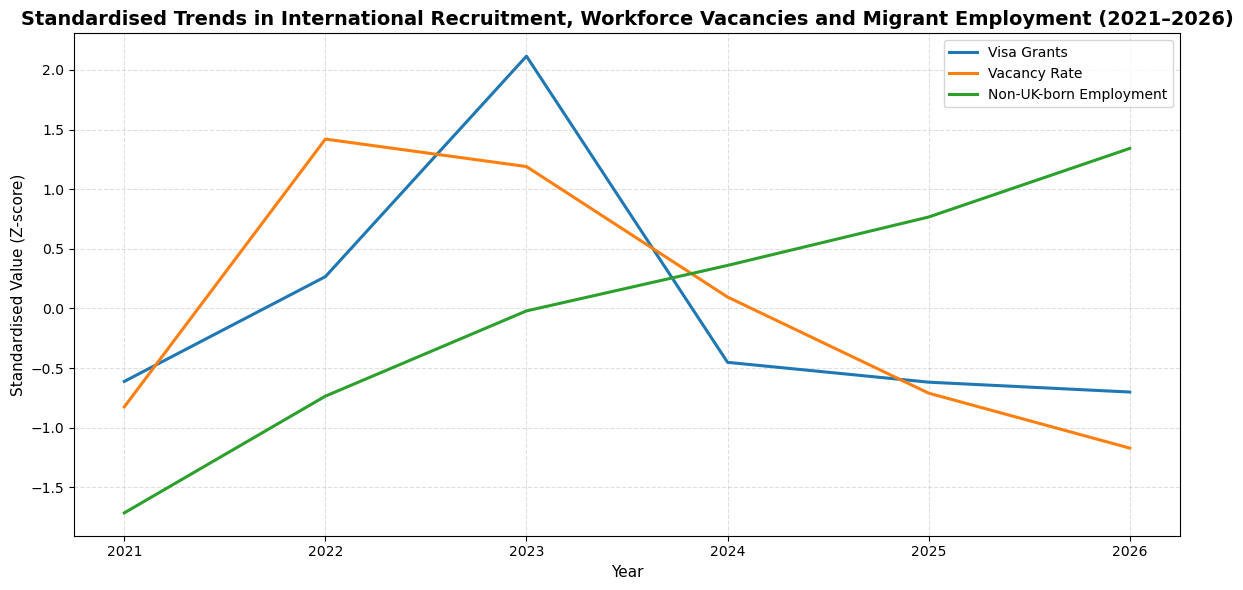

In [13]:
# Select variables
comparison = merged[['Year',
                     'Visa_Grants',
                     'Vacancy_Rt',
                     'NonUK_Born_Emp']].copy()

# Standardise variables
scaler = StandardScaler()

comparison[['Visa_Grants',
            'Vacancy_Rt',
            'NonUK_Born_Emp']] = scaler.fit_transform(
    comparison[['Visa_Grants',
                'Vacancy_Rt',
                'NonUK_Born_Emp']]
)

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    comparison['Year'],
    comparison['Visa_Grants'],
    linewidth=2.2,
    label='Visa Grants'
)

plt.plot(
    comparison['Year'],
    comparison['Vacancy_Rt'],
    linewidth=2.2,
    label='Vacancy Rate'
)

plt.plot(
    comparison['Year'],
    comparison['NonUK_Born_Emp'],
    linewidth=2.2,
    label='Non-UK-born Employment'
)

plt.title(
    'Standardised Trends in International Recruitment, Workforce Vacancies and Migrant Employment (2021–2026)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Standardised Value (Z-score)', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "../04_Output/Figures/Comparative_Workforce_Migration_Trends.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation**:
The figure compares the standardised annual trends in Health and Care Worker visa grants, workforce vacancy rates, and non-UK-born employment between 2021 and 2026. Visa grants increased sharply and reached a peak in 2023 before declining substantially in subsequent years. Vacancy rates followed a similar pattern initially, rising between 2021 and 2023 before falling steadily through 2026. In contrast, non-UK-born employment increased consistently throughout the study period, even as visa grants and vacancy rates declined after 2023. These contrasting trends suggest that changes in international recruitment, workforce shortages, and migrant employment did not occur simultaneously and may reflect delayed or more complex relationships. These relationships are examined further using cross-correlation analysis.

## 4. Correlation Analysis

Pearson correlation analysis is used to examine the strength and direction of relationships between workforce and migration indicators. Unlike cross-correlation analysis, Pearson correlation measures contemporaneous associations between variables without considering time lags.

A correlation matrix and heatmap are produced to summarise the relationships between workforce vacancy rates, turnover rates, visa grants, and non-UK-born employment.

In [14]:
# Select variables for correlation analysis
corr_vars = merged[
    ['Vacancy_Rt',
     'Turnover_Rt',
     'Visa_Grants',
     'NonUK_Born_Emp']
]

# Calculate Pearson correlation matrix
corr_matrix = corr_vars.corr(method='pearson')

# Display matrix
print(corr_matrix.round(3))

# Save for appendix
corr_matrix.round(3).to_csv(
    "../04_Output/Tables/Correlation_Matrix.csv"
)

                Vacancy_Rt  Turnover_Rt  Visa_Grants  NonUK_Born_Emp
Vacancy_Rt           1.000        0.731        0.770          -0.289
Turnover_Rt          0.731        1.000        0.606          -0.836
Visa_Grants          0.770        0.606        1.000          -0.128
NonUK_Born_Emp      -0.289       -0.836       -0.128           1.000


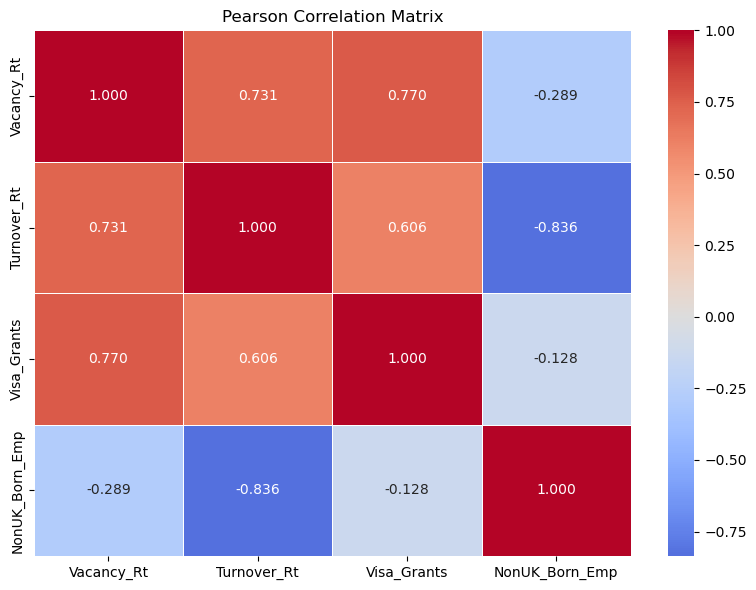

In [15]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "../04_Output/Figures/Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation**:

The correlation matrix indicates the strength and direction of relationships between workforce and migration indicators. Positive values indicate that variables move in the same direction, while negative values indicate inverse relationships. Stronger correlations suggest closer associations between variables, although correlation does not imply causation.

The results provide an initial assessment of workforce and migration relationships before the more detailed cross-correlation analysis presented in the following section.

## 5. Cross-Correlation Analysis

Unlike ordinary correlation, cross-correlation considers the temporal ordering of observations and examines whether changes in one variable precede or follow changes in another. This approach is more appropriate for time-series data because relationships may occur with a time lag rather than simultaneously. Cross-correlation analysis is therefore used to investigate the lagged relationships between Health and Care Worker visa grants, workforce vacancy rates, and non-UK-born employment.

### 5.1 Define the Cross-Correlation Function

A reusable function is developed to calculate and visualise the cross-correlation between two time-series variables. The function evaluates correlations across positive and negative time lags, allowing the analysis to identify whether changes in one variable occur before, after, or simultaneously with changes in another.

In [16]:
def plot_cross_correlation(series1, series2, label1, label2, max_lag=3):
    """
    Calculate and plot the cross-correlation between two time series.
    """

    lags = range(-max_lag, max_lag + 1)
    correlations = []

    for lag in lags:

        if lag < 0:
            corr = series1[:lag].corr(series2[-lag:])

        elif lag > 0:
            corr = series1[lag:].corr(series2[:-lag])

        else:
            corr = series1.corr(series2)

        correlations.append(corr)

    # Create results table
    results = pd.DataFrame({
        'Lag (Years)': list(lags),
        'Correlation': correlations
    })

    # Find the strongest correlation
    strongest = results.iloc[results['Correlation'].abs().idxmax()]

    # Plot
    plt.figure(figsize=(8,5))

    plt.stem(results['Lag (Years)'],
             results['Correlation'])

    plt.title(
        f'Cross-Correlation: {label1} vs {label2}',
        fontsize=13,
        fontweight='bold'
    )

    plt.xlabel('Lag (Years)', fontsize=11)
    plt.ylabel('Correlation Coefficient', fontsize=11)

    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()

    plt.show()

    print("="*50)
    print(f"Variables: {label1} vs {label2}")
    print(f"Strongest correlation : {strongest['Correlation']:.3f}")
    print(f"Lag (Years)          : {int(strongest['Lag (Years)'])}")
    print("="*50)

    return results

**Interpretation**:
The function computes cross-correlation coefficients across a range of positive and negative lags and presents the results graphically. Positive lags indicate that the first variable leads the second, whereas negative lags indicate that the second variable leads the first. The highest correlation identifies the lag at which the relationship between the two variables is strongest.

### 5.2 Cross-Correlation between Visa Grants and Vacancy Rate
Cross-correlation is used to examine whether changes in Health and Care Worker visa grants precede, follow, or occur simultaneously with changes in workforce vacancy rates. Identifying the lag with the strongest correlation provides insight into the temporal relationship between international recruitment and workforce shortages.

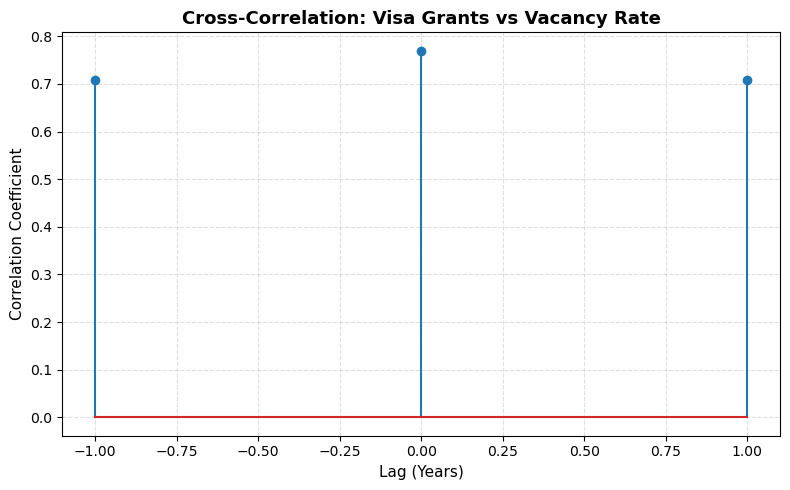

Variables: Visa Grants vs Vacancy Rate
Strongest correlation : 0.770
Lag (Years)          : 0


,Lag (Years),Correlation
0,-1,0.707940
1,0,0.769756
2,1,0.707940


In [17]:
# Cross-correlation: Visa Grants vs Vacancy Rate
visa_vacancy_ccf = plot_cross_correlation(
    merged['Visa_Grants'],
    merged['Vacancy_Rt'],
    'Visa Grants',
    'Vacancy Rate',
    max_lag=1
)

# Display correlation table
visa_vacancy_ccf

In [18]:
visa_vacancy_ccf.to_csv(
    "../04_Output/Tables/CrossCorrelation_Visa_vs_Vacancy.csv",
    index=False
)

**Interpretation**:
The cross-correlation analysis indicates a positive relationship between Health and Care Worker visa grants and workforce vacancy rates across all examined lags. The strongest correlation (r = 0.770) occurred at **lag 0**, suggesting that changes in visa grants and vacancy rates were most closely associated within the same year rather than with a one-year lead or lag. The slightly lower correlations at **lag -1** and **lag +1** (r = 0.708) indicate that the relationship weakened when a one-year time shift was introduced. Given the limited number of annual observations (2021–2026), these findings should be interpreted with caution and regarded as indicative rather than conclusive.

### 5.3 Cross-Correlation between Visa Grants and Non-UK-born Employment

Cross-correlation is used to examine whether changes in Health and Care Worker visa grants precede, follow, or occur simultaneously with changes in non-UK-born employment. As the overlapping annual data cover only the period from 2021 to 2026, the analysis is restricted to a maximum lag of ±1 year to ensure that each correlation coefficient is based on an adequate number of observations.

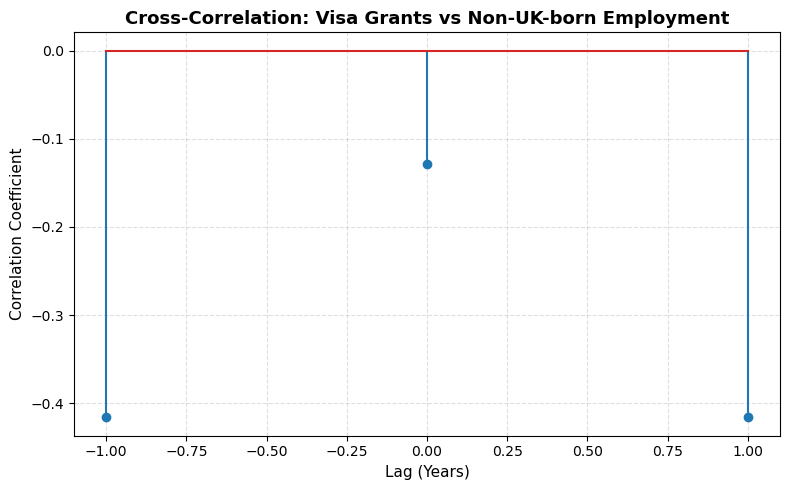

Variables: Visa Grants vs Non-UK-born Employment
Strongest correlation : -0.416
Lag (Years)          : -1


,Lag (Years),Correlation
0,-1,-0.416136
1,0,-0.128070
2,1,-0.416136


In [19]:
# Cross-correlation: Visa Grants vs Non-UK-born Employment
visa_employment_ccf = plot_cross_correlation(
    merged['Visa_Grants'],
    merged['NonUK_Born_Emp'],
    'Visa Grants',
    'Non-UK-born Employment',
    max_lag=1
)

# Display correlation table
visa_employment_ccf

In [20]:
visa_employment_ccf.to_csv(
    "../04_Output/Tables/CrossCorrelation_Visa_vs_Employment.csv",
    index=False
)

**Interpretation**:
The cross-correlation analysis indicates a weak negative relationship between Health and Care Worker visa grants and non-UK-born employment across all examined lags. The strongest correlation (r = -0.416) occurred at both **lag -1** and **lag +1**, while the contemporaneous relationship at **lag 0** was weaker (r = -0.128). These findings suggest that changes in visa grants were not closely associated with changes in non-UK-born employment during the same year or within a one-year lead or lag. Given the limited number of annual observations (2021–2026), these results should be interpreted with caution and regarded as indicative rather than conclusive.

### 5.4 Cross-Correlation between Workforce Vacancy Rate and Non-UK-born Employment

Cross-correlation is used to examine whether changes in workforce vacancy rates precede, follow, or occur simultaneously with changes in non-UK-born employment. As with the previous analyses, the maximum lag is restricted to ±1 year because only six annual observations are available.

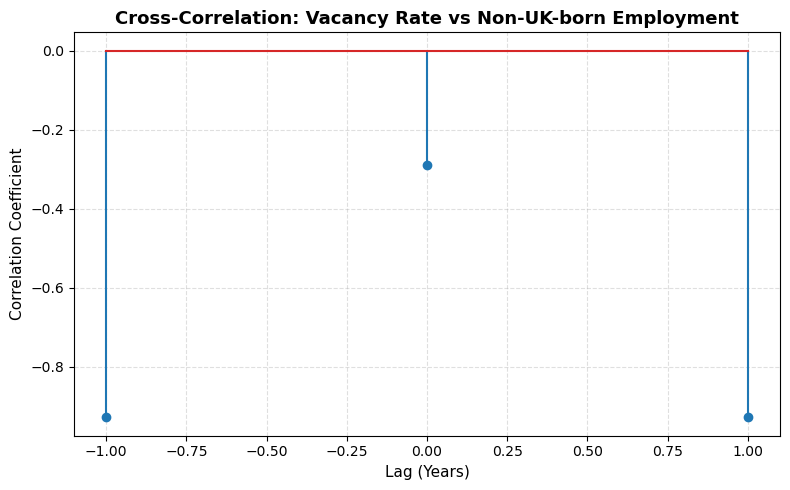

Variables: Vacancy Rate vs Non-UK-born Employment
Strongest correlation : -0.928
Lag (Years)          : -1


,Lag (Years),Correlation
0,-1,-0.928054
1,0,-0.289235
2,1,-0.928054


In [21]:
# Cross-correlation: Vacancy Rate vs Non-UK-born Employment
vacancy_employment_ccf = plot_cross_correlation(
    merged['Vacancy_Rt'],
    merged['NonUK_Born_Emp'],
    'Vacancy Rate',
    'Non-UK-born Employment',
    max_lag=1
)

# Display correlation table
vacancy_employment_ccf

In [22]:
vacancy_employment_ccf.to_csv(
    "../04_Output/Tables/CrossCorrelation_Vacancy_vs_Employment.csv",
    index=False
)

**Interpretation**:
The cross-correlation analysis indicates a strong negative relationship between workforce vacancy rates and non-UK-born employment. The strongest correlation (r = -0.928) occurred at both **lag -1** and **lag +1**, while the contemporaneous relationship at **lag 0** was considerably weaker (r = -0.289). These findings suggest that higher levels of non-UK-born employment were associated with lower workforce vacancy rates, although the strongest relationship was observed when a one-year lead or lag was considered rather than within the same year. Given the limited number of annual observations (2021–2026), these findings should be interpreted with caution and regarded as indicative rather than conclusive.

### 5.5 Summary of Cross-Correlation Findings

Table 5.1 summarises the strongest cross-correlation observed for each pair of variables analysed.

In [23]:
summary_ccf = pd.DataFrame({
    'Variable Pair': [
        'Visa Grants vs Vacancy Rate',
        'Visa Grants vs Non-UK-born Employment',
        'Vacancy Rate vs Non-UK-born Employment'
    ],
    'Strongest Correlation (r)': [
        0.770,
        -0.416,
        -0.928
    ],
    'Lag (Years)': [
        0,
        -1,
        -1
    ]
})

summary_ccf

,Variable Pair,Strongest Correlation (r),Lag (Years)
0,Visa Grants vs Vacancy Rate,0.770,0
1,Visa Grants vs Non-UK-born Employment,-0.416,-1
2,Vacancy Rate vs Non-UK-born Employment,-0.928,-1


**Interpretation**:
The cross-correlation analysis revealed different temporal relationships between the study variables. Health and Care Worker visa grants and workforce vacancy rates showed the strongest positive relationship (r = 0.770) at lag 0, indicating that changes in both variables were most closely associated within the same year. In contrast, visa grants and non-UK-born employment exhibited a weak negative relationship (r = -0.416), suggesting limited temporal association. The strongest relationship was observed between workforce vacancy rates and non-UK-born employment (r = -0.928) at a one-year lag, indicating that increases in non-UK-born employment were associated with lower workforce vacancy rates after accounting for a one-year lead or lag. As these findings are based on only six annual observations (2021–2026), they should be interpreted as indicative rather than conclusive.